# 03 — Data Processing

Pipeline: `venues_raw.csv` (OSM) → enrich; `steps_venues_raw.csv`
(Massive-STEPS) → filter kategori wisata → merge dengan OSM enrichment.

Semua tahap di sini menunjukkan **before/after** (jumlah row, distribusi) —
bagian "cleaning data" yang masuk preprocessing, bukan data collection.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

## A. Enrich venue OSM

Masalah yang ditangani:
1. **Boundary mismatch** — bbox persegi awal overlap sebagian Bekasi/Depok/
   Tangerang. Fix: filter pakai area administratif asli DKI Jakarta.
2. **Duplikat entitas** — venue besar (cth Monas) punya >1 elemen OSM
   (gerbang utara/selatan/timur/barat + taman + monumen) yang sebenarnya
   1 destinasi. Fix: `dedupe_clusters()` cluster transitif by jarak+nama.
3. **Jam buka** — sebagian venue OSM tidak punya tag `opening_hours`,
   pakai default per kategori (ditandai `hours_source=default`).

In [2]:
osm_raw = pd.read_csv("../../data/raw/venues_raw.csv")
osm_enriched = pd.read_csv("../../data/processed/venues_enriched.csv")
print(f"OSM raw: {len(osm_raw)} venue")
print(f"OSM enriched: {len(osm_enriched)} venue (kolom jam buka + metrik ditambahkan, jumlah row sama)")

OSM raw: 6166 venue
OSM enriched: 6166 venue (kolom jam buka + metrik ditambahkan, jumlah row sama)


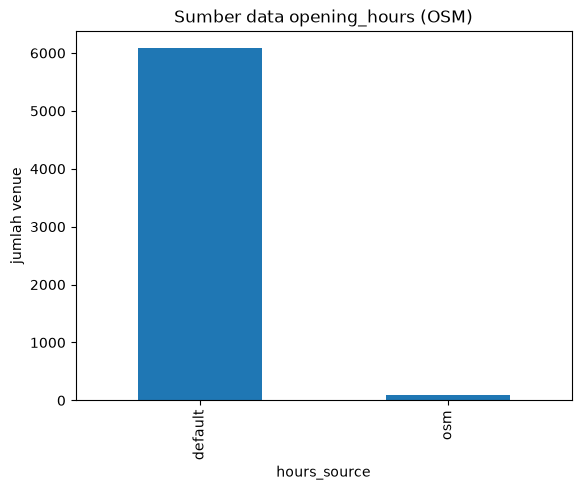

In [3]:
osm_enriched["hours_source"].value_counts().plot(kind="bar", title="Sumber data opening_hours (OSM)")
plt.ylabel("jumlah venue")
plt.show()

**Catatan limitasi riset**: `unique_visitors`/`time_spent` versi OSM-only
sintetis (lognormal per kategori) — dipakai hanya untuk venue yang TIDAK
match ke Massive-STEPS di tahap merge (bagian C).

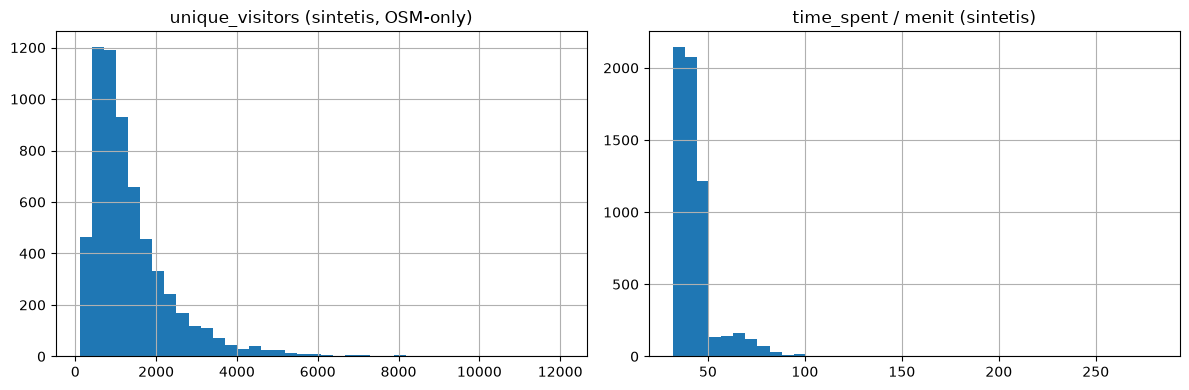

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
osm_enriched["unique_visitors"].hist(bins=40, ax=axes[0])
axes[0].set_title("unique_visitors (sintetis, OSM-only)")
osm_enriched["time_spent"].hist(bins=40, ax=axes[1])
axes[1].set_title("time_spent / menit (sintetis)")
plt.tight_layout()
plt.show()

## B. Filter Massive-STEPS ke kategori wisata

**Kenapa perlu filter ketat**: kategori check-in di Foursquare dipilih
BEBAS oleh user saat check-in, bukan ground truth kurasi venue. Dataset
mentah didominasi Office/Home/Building/Restaurant (check-in umum,
bukan khusus wisata) — lihat grafik kategori di notebook 02.

**Iterasi 1** (whitelist 43 kategori by keyword match longgar, termasuk
Plaza/Park/Garden/Zoo/Water Park/Art Gallery/dst) menghasilkan 1.018 venue,
tapi spot-check manual menemukan bocor signifikan:

In [5]:
steps_venues = pd.read_csv("../../data/raw/steps_venues_raw.csv")

print("Contoh noise yang lolos whitelist longgar (kategori generic):")
print("  Plaza:", steps_venues[steps_venues.venue_category == "Plaza"]["name"].head(4).tolist())
print("  Art Gallery:", steps_venues[steps_venues.venue_category == "Art Gallery"]["name"].head(4).tolist())
print("  Scenic Lookout:", steps_venues[steps_venues.venue_category == "Scenic Lookout"]["name"].head(4).tolist())

Contoh noise yang lolos whitelist longgar (kategori generic):
  Plaza: ['Rasuna Epicentrum', 'Plaza Barat', 'Orion Plaza', 'Fountain Area']
  Art Gallery: ['ruangrupa', 'DC House - Studio', 'Simprug Gallery', 'SmartFren Gallery']
  Scenic Lookout: ['StarBak (Sekitar Wisma Bakrie)', 'Jl. H Ramli', 'Cisarua Puncak', 'SkyLift Indonesia']


"Rasuna Epicentrum"/"Roxy" itu mall, "SmartFren Gallery"/"Galeri Indosat"
itu showroom telco, "Lampu merah pulo gadung" jelas bukan venue wisata —
semua lolos karena nama kategori Foursquare-nya kebetulan match keyword
wisata ("Plaza", "Gallery", "Lookout"), bukan karena tempatnya memang wisata.

**Iterasi 2** (final, dipakai): whitelist dipersempit ke 14 kategori yang
secara nama relatif spesifik (Museum, Temple, Beach, Monument/Landmark,
Historic Site, Theme Park, Zoo, Aquarium, dst — kategori generic seperti
Plaza/Park/Garden/Art Gallery/Scenic Lookout di-DROP sepenuhnya), ditambah
keyword-exclude nama tahap 2 (hotel, kantor, bank, lampu merah, puskesmas,
cuci mobil, dst) untuk membuang sisa noise yang masih lolos kategori.

In [6]:
steps_filtered = pd.read_csv("../../data/processed/steps_filtered.csv")

n_before = len(steps_venues)
n_after = len(steps_filtered)
print(f"Venue Massive-STEPS sebelum filter kategori: {n_before}")
print(f"Venue setelah whitelist kategori (final, 14 kategori) "
      f"+ keyword-exclude nama: {n_after} ({n_after / n_before:.1%} dari total)")
print()
print("Kategori yang DIPAKAI (final):", config.STEPS_TOURISM_CATEGORIES)

Venue Massive-STEPS sebelum filter kategori: 49291
Venue setelah whitelist kategori (final, 14 kategori) + keyword-exclude nama: 340 (0.7% dari total)

Kategori yang DIPAKAI (final): ['Aquarium', 'Art Museum', 'Beach', 'Historic Site', 'History Museum', 'Monument / Landmark', 'Museum', 'Science Museum', 'Temple', 'Buddhist Temple', 'Theme Park', 'Theme Park Ride / Attraction', 'Tourist Information Center', 'Zoo']


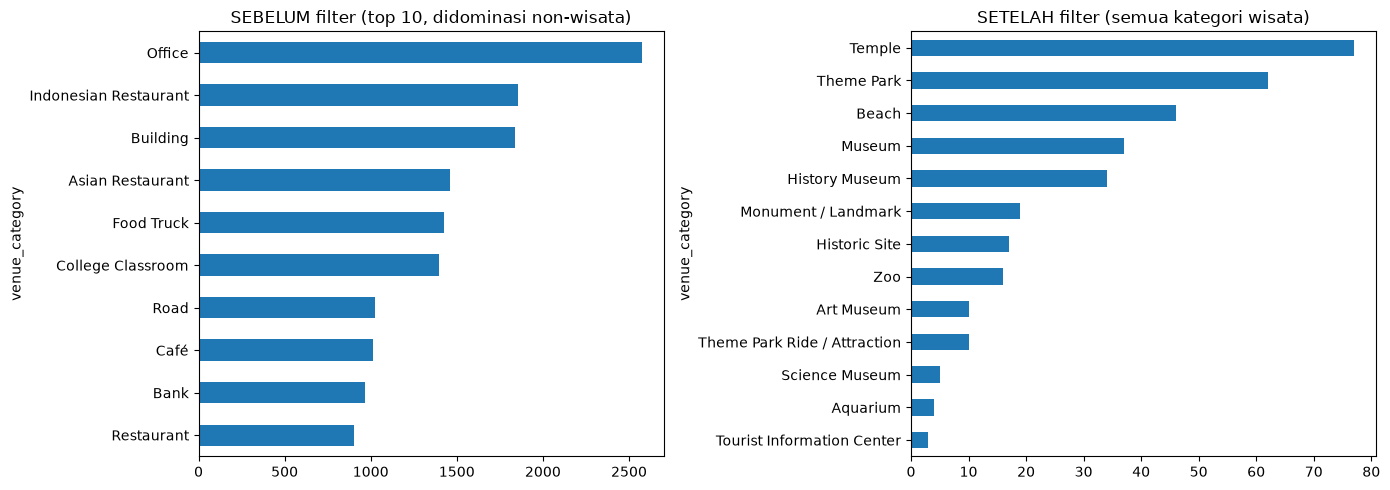

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps_venues["venue_category"].value_counts().head(10).plot(
    kind="barh", ax=axes[0], title="SEBELUM filter (top 10, didominasi non-wisata)")
axes[0].invert_yaxis()
steps_filtered["venue_category"].value_counts().plot(
    kind="barh", ax=axes[1], title="SETELAH filter (semua kategori wisata)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## C. Merge Massive-STEPS + OSM enrichment

Massive-STEPS (filtered) jadi tulang punggung (POI nyata + `checkin_count`
popularitas asli), dilengkapi `opening_hours`/`References`/`osm_url` dari
OSM venue terdekat (radius 150m). Venue yang tidak match tetap masuk,
kolom OSM default/kosong (`hours_source=default`).

In [8]:
merged = pd.read_csv("../../data/processed/merged_venues.csv")
n_match = (merged["hours_source"] == "osm").sum()
print(f"Venue Massive-STEPS (filtered, input merge): {len(steps_filtered)}")
print(f"Berhasil match ke OSM: {n_match} ({n_match / len(merged):.1%})")
print(f"Tidak match (kolom OSM default/kosong): {len(merged) - n_match}")
print(f"Venue final setelah merge: {len(merged)}")

Venue Massive-STEPS (filtered, input merge): 340
Berhasil match ke OSM: 47 (13.8%)
Tidak match (kolom OSM default/kosong): 293
Venue final setelah merge: 340


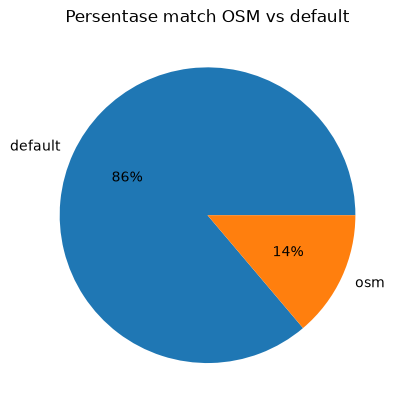

In [9]:
merged["hours_source"].value_counts().plot(
    kind="pie", autopct="%1.0f%%", title="Persentase match OSM vs default", ylabel="")
plt.show()

## Ringkasan alur before/after (data collection → preprocessing)

| Tahap | Jumlah |
|---|---|
| Check-in Massive-STEPS (mentah) | 412.100 |
| Setelah drop null lat/lon/name | 333.191 |
| Venue unik (agregasi per venue_id) | 49.291 |
| Setelah whitelist kategori wisata | 348 |
| Setelah keyword-exclude nama | 340 |
| Setelah merge dengan OSM | 340 (tetap, OSM cuma melengkapi kolom) |